# 02｜Wafer Quality 與 Spatial Analysis

## 這份 Notebook 要做什麼？

01 已經把 Measurement 的缺失來源、空間座標、Lot metadata 和 Process QC 整理好。這一份才真正開始看 **Wafer 的 Si Etch 品質到底呈現什麼樣的變化**。

我想回答四個問題：

1. 88 片 Wafer 的平均 Si Etch 與片內變異大概落在哪個範圍。
2. 不同 Lot 之間有沒有明顯位移。
3. 同一個 Lot 裡，Wafer number 往後時，品質有沒有固定的 sequence trend。
4. 89 個空間位置的高低分布是不是每片都差不多，還是每片都長得不一樣。

這一份先把 Quality 本身的結構看清楚。後面的 03 才會接著問：**Process signals 是否也跟同一個 wafer sequence 一起變化。**


## 1. 載入套件

這一份主要會做表格整理、統計計算和畫圖，所以先把會用到的套件載入。這一步還沒有讀資料，也沒有改任何檔案。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)

print("套件載入完成")

套件載入完成


### 這個結果代表什麼？

顯示「套件載入完成」代表目前的分析環境可以正常使用。這裡還沒有產生任何分析結果，只是確認後面的程式可以開始跑。


## 2. 設定資料路徑

02 直接使用 01 已經整理好的：

`data/interim/measurement_qc.csv`

我不再回頭讀 Raw CSV 重新清一次，這樣可以確保 01 做過的 interpolation flag、座標轉換和 Lot metadata 都被保留下來。

分析後產生的表格會放在 `data/processed/`，圖片則放在 `reports/figures/`。


In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

measurement_path = INTERIM_DATA_DIR / "measurement_qc.csv"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

assert measurement_path.exists(), (
    f"找不到 01 輸出的 canonical measurement artifact: {measurement_path}"
)

print("專案根目錄：", PROJECT_ROOT)
print("Measurement Input：", measurement_path)
print("Processed Data：", PROCESSED_DATA_DIR)
print("Figure Directory：", FIGURE_DIR)

專案根目錄： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence
Measurement Input： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\interim\measurement_qc.csv
Processed Data： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\processed
Figure Directory： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\reports\figures


### 這個結果代表什麼？

路徑都成功建立，而且 Measurement Input 指向的是 01 輸出的 `measurement_qc.csv`。所以 02 是接著 01 往下分析，不是另外做一套資料清理。


## 3. 載入並確認 01 的 Measurement 輸出檔

在開始做 Quality Analysis 前，我先做一次簡單的入口檢查，避免 01 的輸出檔被改過或讀錯版本。

這裡會確認：

- 資料是不是 7,832 筆
- 是否還是 10 個 Lots、88 片 measured wafers
- 每片是不是都有 89 筆 measurement records
- `experiment_key + x_mm + y_mm` 有沒有重複

如果這些基本條件對不上，02 就不應該繼續往下分析。


In [3]:
measurement_df = pd.read_csv(measurement_path)

measurement_df["date"] = pd.to_datetime(
    measurement_df["date"],
    errors="raise",
)

if measurement_df["postox_was_interpolated"].dtype != bool:
    interpolation_flag_map = {
        "True": True,
        "False": False,
        True: True,
        False: False,
    }

    measurement_df["postox_was_interpolated"] = (
        measurement_df["postox_was_interpolated"]
        .map(interpolation_flag_map)
    )

    assert measurement_df[
        "postox_was_interpolated"
    ].notna().all()

required_columns = {
    "experiment_key",
    "lot_number",
    "wafer_number",
    "date",
    "conditioning",
    "conditioning_count",
    "conditioning_surface",
    "si_etch",
    "oxide_etch",
    "postox_was_interpolated",
    "x_mm",
    "y_mm",
    "radius_mm",
}

missing_columns = required_columns - set(measurement_df.columns)

assert not missing_columns, (
    f"measurement_qc.csv 缺少必要欄位：{sorted(missing_columns)}"
)

records_per_wafer = (
    measurement_df.groupby("experiment_key").size()
)

duplicate_spatial_keys = measurement_df.duplicated(
    subset=["experiment_key", "x_mm", "y_mm"]
).sum()

assert len(measurement_df) == 7832
assert measurement_df["experiment_key"].nunique() == 88
assert measurement_df["lot_number"].nunique() == 10
assert records_per_wafer.eq(89).all()
assert duplicate_spatial_keys == 0

print("Measurement Shape：", measurement_df.shape)
print("Lot 數量：", measurement_df["lot_number"].nunique())
print("Measured Wafer 數量：", measurement_df["experiment_key"].nunique())
print("每片 Measurement Records：", records_per_wafer.min(), "～", records_per_wafer.max())
print("Wafer + XY Duplicate Keys：", duplicate_spatial_keys)

Measurement Shape： (7832, 20)
Lot 數量： 10
Measured Wafer 數量： 88
每片 Measurement Records： 89 ～ 89
Wafer + XY Duplicate Keys： 0


### 這個結果代表什麼？

讀進來的資料是：

- **7,832 rows × 20 columns**
- **10 個 Lots**
- **88 片 measured wafers**
- 每片都是 **89 筆 measurement records**
- Wafer + XY duplicate = **0**

所以 01 輸出的資料結構目前沒有被破壞，02 可以直接接著使用。Missing、interpolation 和 spatial grid 的品質問題已經在 01 驗證過，這裡不重做第二次。


# Part A｜Wafer-Level Quality

## 4. 建立每片 Wafer 的 Quality KPI

原始資料有 7,832 筆，因為一片 Wafer 有 89 個空間量測點。但接下來不管是比較 Lot、看 wafer sequence，還是之後做 Virtual Metrology，真正的分析單位都應該是一片 Wafer。

所以我先把 89 個位置整理成幾個 Wafer-level 指標：

- `mean_si_etch`：整片 Wafer 的平均 Silicon Etch Depth
- `std_si_etch`：89 個位置的離散程度
- `range_si_etch`：最大值減最小值，對單一極端點很敏感
- `p90_width_si_etch`：P95 - P05，比 Range 不容易被單一極端點拉大
- `cv_si_etch_pct`：Std / Mean × 100%，看相對的空間變異
- `interpolated_points`：這片 Wafer 有多少位置使用資料提供者重建的 post-oxide 值

這些都只是描述資料的 KPI，不是 Good / Bad Wafer 的規格。


In [4]:
wafer_quality_df = (
    measurement_df
    .groupby(
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "date",
            "conditioning",
            "conditioning_count",
            "conditioning_surface",
        ],
        as_index=False,
    )
    .agg(
        n_points=("si_etch", "size"),
        mean_si_etch=("si_etch", "mean"),
        median_si_etch=("si_etch", "median"),
        std_si_etch=("si_etch", lambda x: x.std(ddof=0)),
        min_si_etch=("si_etch", "min"),
        max_si_etch=("si_etch", "max"),
        p05_si_etch=("si_etch", lambda x: x.quantile(0.05)),
        p95_si_etch=("si_etch", lambda x: x.quantile(0.95)),
        mean_oxide_etch=("oxide_etch", "mean"),
        std_oxide_etch=("oxide_etch", lambda x: x.std(ddof=0)),
        interpolated_points=("postox_was_interpolated", "sum"),
    )
)

wafer_quality_df["range_si_etch"] = (
    wafer_quality_df["max_si_etch"]
    - wafer_quality_df["min_si_etch"]
)

wafer_quality_df["p90_width_si_etch"] = (
    wafer_quality_df["p95_si_etch"]
    - wafer_quality_df["p05_si_etch"]
)

wafer_quality_df["cv_si_etch_pct"] = (
    wafer_quality_df["std_si_etch"]
    / wafer_quality_df["mean_si_etch"]
    * 100
)

wafer_quality_df["interpolated_pct"] = (
    wafer_quality_df["interpolated_points"]
    / wafer_quality_df["n_points"]
    * 100
)

wafer_quality_df = (
    wafer_quality_df
    .sort_values(["lot_number", "wafer_number"])
    .reset_index(drop=True)
)

assert len(wafer_quality_df) == 88
assert wafer_quality_df["n_points"].eq(89).all()

print("Wafer-Level Rows：", len(wafer_quality_df))

wafer_quality_df[
    [
        "mean_si_etch",
        "std_si_etch",
        "range_si_etch",
        "p90_width_si_etch",
        "cv_si_etch_pct",
    ]
].describe().T

Wafer-Level Rows： 88


,count,mean,std,min,25%,50%,75%,max
mean_si_etch,88.0,43.668120,0.401909,42.942928,43.349077,43.667601,43.983902,44.376304
std_si_etch,88.0,3.586133,0.100173,3.407034,3.514952,3.570351,3.660324,3.845149
range_si_etch,88.0,11.722373,1.180424,11.091000,11.434525,11.536750,11.773675,22.300400
p90_width_si_etch,88.0,10.682879,0.196150,10.237520,10.546560,10.689460,10.820270,11.123280
cv_si_etch_pct,88.0,8.211430,0.182921,7.904162,8.092702,8.191840,8.309548,8.946925


### 這個結果代表什麼？

88 片 Wafer 的結果顯示：

- `mean_si_etch` 平均約 **43.67 µm**
- 不同 Wafer 的 Mean Si Etch 標準差約 **0.40 µm**
- Mean Si Etch 大約落在 **42.94–44.38 µm**
- 每片 Wafer 內部的 `std_si_etch` 平均約 **3.59 µm**
- `cv_si_etch_pct` 平均約 **8.21%**

這代表不同 Wafer 的「整片平均 Etch Level」其實相對集中，但同一片 Wafer 裡 89 個位置之間的差異明顯更大，所以後面不能只看 Wafer mean，Spatial Variation 也很重要。

另外，`range_si_etch` 最大到 **22.30 µm**，但 `p90_width_si_etch` 最大只有約 **11.12 µm**。兩者差很多，表示至少有一片 Wafer 的 Max-Min 很可能被少數極端位置拉大，所以後面判斷 Uniformity 時不能只依賴 Range。


## 5. 整體 Wafer Quality Distribution 與 Mean–Variation 關係

接著我想先看一個簡單問題：

> 平均 Etch Depth 比較高的 Wafer，片內相對變異是不是也通常比較高？

這裡同時看 Pearson 和 Spearman：

- Pearson 比較偏向看線性關係
- Spearman 比較偏向看單調關係

不過這只是資料上的關聯，不是因果關係。而且 CV 的分母本身就有 Mean，所以 Mean 和 CV 之間的相關不能直接當成製程機制的證據。


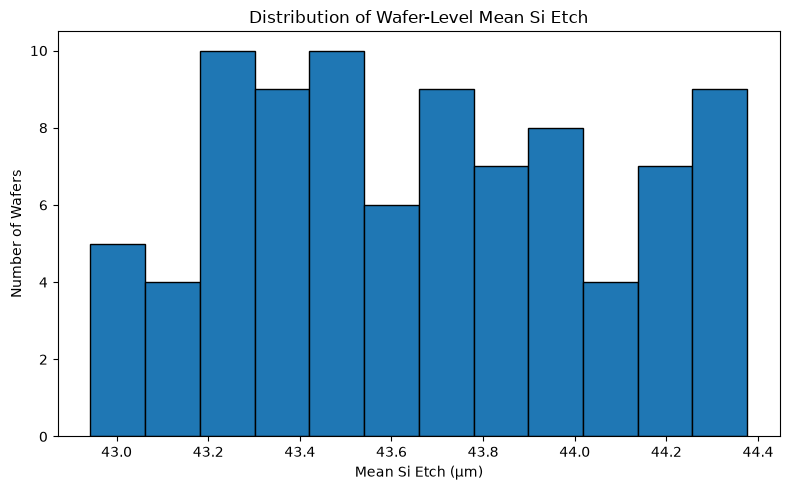

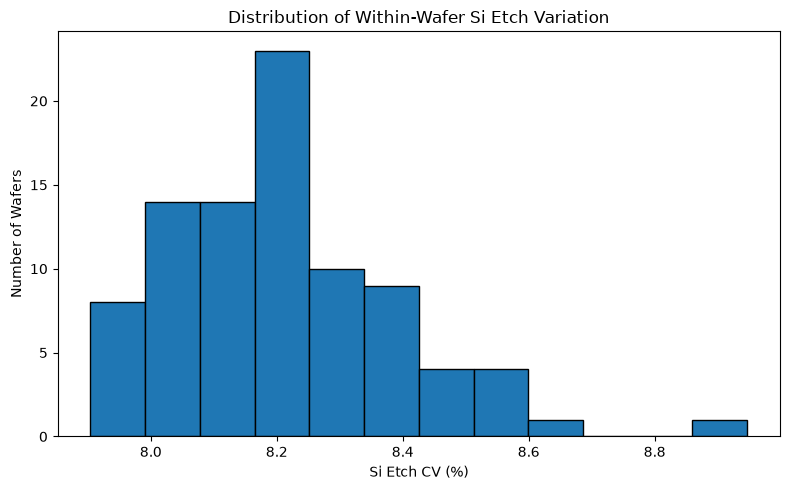

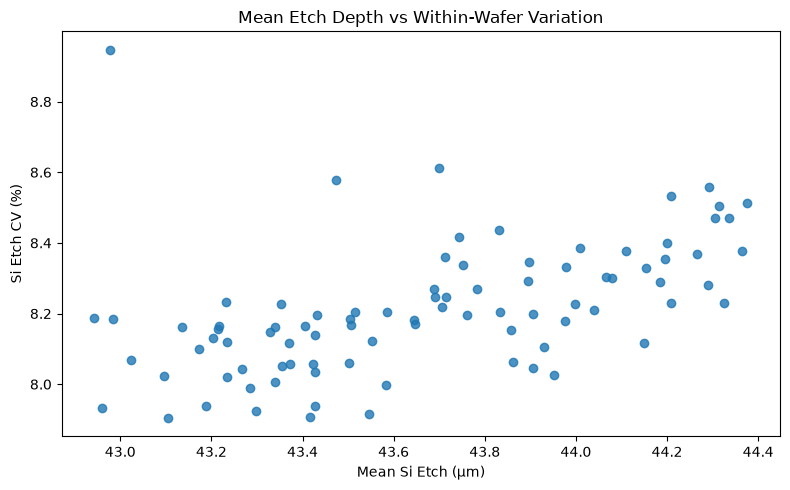

Pearson Correlation： 0.4894
Spearman Correlation： 0.6214


,experiment_key,lot_number,wafer_number,mean_si_etch,min_si_etch,max_si_etch,range_si_etch,p90_width_si_etch,cv_si_etch_pct,interpolated_points
55,2024-08-01_07,6,7,42.977328,28.6530,50.9534,22.3004,10.62454,8.946925,0
20,2024-07-09_02,3,2,43.905554,39.2308,52.0478,12.8170,10.76920,8.198847,0
9,2024-07-05_01,2,1,44.208571,40.4464,52.6825,12.2361,11.12328,8.531945,0
39,2024-07-19_01,5,1,44.314201,40.5720,52.7809,12.2089,11.04118,8.504150,0
75,2024-08-21_01,9,1,44.291687,40.5155,52.6704,12.1549,10.98714,8.559635,0


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    wafer_quality_df["mean_si_etch"],
    bins=12,
    edgecolor="black",
)
ax.set_xlabel("Mean Si Etch (µm)")
ax.set_ylabel("Number of Wafers")
ax.set_title("Distribution of Wafer-Level Mean Si Etch")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    wafer_quality_df["cv_si_etch_pct"],
    bins=12,
    edgecolor="black",
)
ax.set_xlabel("Si Etch CV (%)")
ax.set_ylabel("Number of Wafers")
ax.set_title("Distribution of Within-Wafer Si Etch Variation")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    wafer_quality_df["mean_si_etch"],
    wafer_quality_df["cv_si_etch_pct"],
    alpha=0.8,
)
ax.set_xlabel("Mean Si Etch (µm)")
ax.set_ylabel("Si Etch CV (%)")
ax.set_title("Mean Etch Depth vs Within-Wafer Variation")
plt.tight_layout()
plt.show()

mean_cv_pearson = (
    wafer_quality_df["mean_si_etch"]
    .corr(
        wafer_quality_df["cv_si_etch_pct"],
        method="pearson",
    )
)

mean_cv_spearman = (
    wafer_quality_df["mean_si_etch"]
    .corr(
        wafer_quality_df["cv_si_etch_pct"],
        method="spearman",
    )
)

print("Pearson Correlation：", round(mean_cv_pearson, 4))
print("Spearman Correlation：", round(mean_cv_spearman, 4))

largest_range_wafers = (
    wafer_quality_df
    .nlargest(5, "range_si_etch")
    [
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "mean_si_etch",
            "min_si_etch",
            "max_si_etch",
            "range_si_etch",
            "p90_width_si_etch",
            "cv_si_etch_pct",
            "interpolated_points",
        ]
    ]
)

largest_range_wafers

### 這個結果代表什麼？

結果是：

- Pearson ≈ **0.4894**
- Spearman ≈ **0.6214**

兩個值都是正的，而且 Spearman 比 Pearson 高，表示 Mean Si Etch 越高時，CV 整體上也有往上走的趨勢，而且這個趨勢用「排名」看比純線性更明顯。

但這不能解讀成「Mean Etch Depth 造成 Uniformity 變差」，因為目前只是觀察到關聯，而且 CV 本身就含有 Mean。

另外，`2024-08-01_07` 的 Range 是 **22.30 µm**，但 P90 width 只有約 **10.62 µm**。這再次提醒我：它的 Range 很可能被少數極端 spatial points 拉大，後面需要直接回到空間位置檢查。


# Part B｜Lot 與 Wafer Sequence

## 6. Lot-Level Quality Comparison

接著把 Wafer-level KPI 按 Lot 彙整，看看不同 Lot 的：

- 平均 Etch Level
- Lot 內 Wafer-to-Wafer 變異
- 平均 CV

這裡只做描述性比較。因為每個 Lot 的 measured wafer 數不完全一樣，而且 Lot、日期和 Conditioning 也不是獨立隨機安排的，所以現在不能看到 Lot 差異就直接說是 Conditioning 造成的。


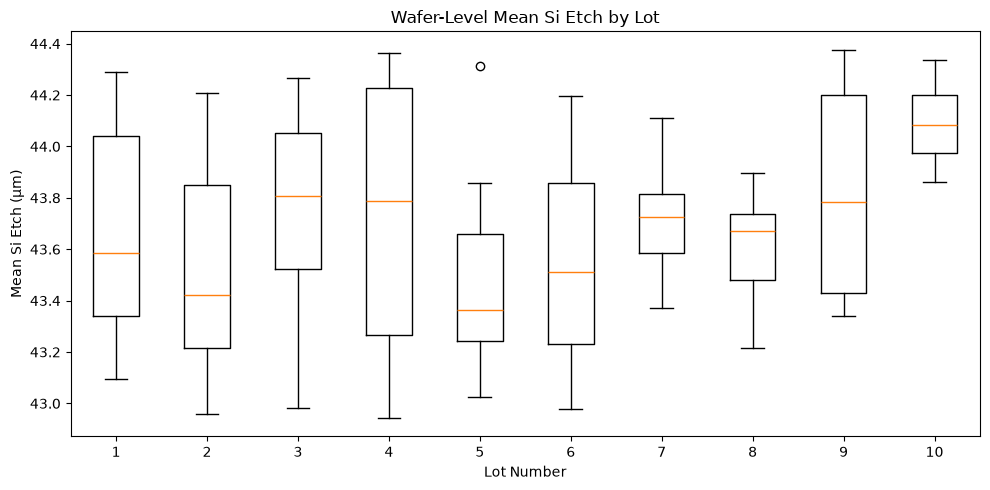

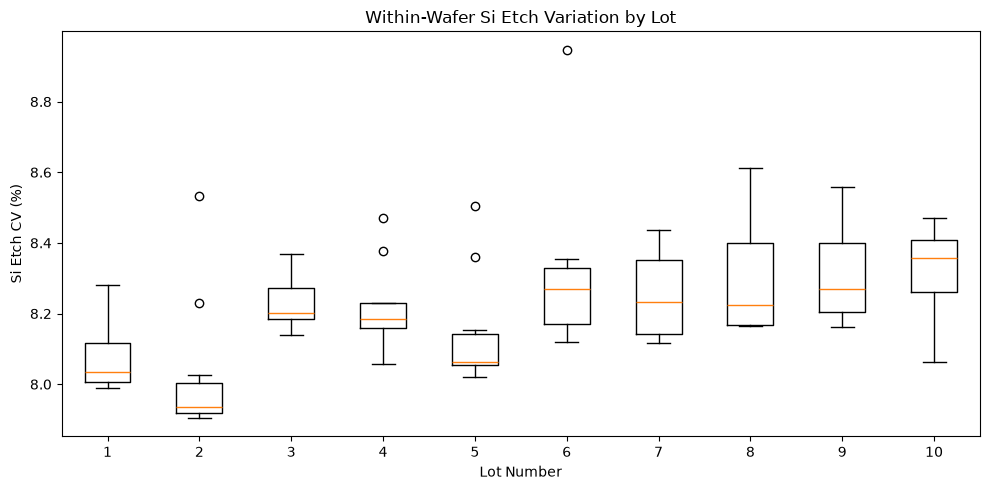

,lot_number,conditioning,conditioning_count,conditioning_surface,n_wafers,mean_of_mean_si_etch,wafer_to_wafer_std,min_mean_si_etch,max_mean_si_etch,mean_cv_si_etch_pct,max_cv_si_etch_pct
0,1,3C,3,Chuck,9,43.679407,0.402291,43.096928,44.288991,8.078256,8.281023
1,2,1C,1,Chuck,10,43.530817,0.424104,42.960672,44.208571,8.024448,8.531945
2,3,9C,9,Chuck,10,43.761885,0.376585,42.983073,44.266010,8.227195,8.370073
3,4,3C - Si,3,Si wafer,10,43.728478,0.504002,42.942928,44.364903,8.215639,8.471969
4,5,1C - Si,1,Si wafer,10,43.481078,0.364562,43.024626,44.314201,8.141890,8.504150
5,6,9C - Si,9,Si wafer,10,43.557539,0.395055,42.977328,44.195029,8.310991,8.946925
6,7,3C - SiO2,3,SiO2 wafer,6,43.719150,0.230161,43.370857,44.110848,8.253370,8.435704
7,8,3C - SiO2,3,SiO2 wafer,10,43.613837,0.198657,43.217525,43.896178,8.307088,8.611605
8,9,3C,3,Chuck,9,43.807341,0.393602,43.340424,44.376304,8.317900,8.559635
9,10,3C - SiO2,3,SiO2 wafer,4,44.090644,0.175592,43.862195,44.337099,8.311929,8.470729


In [6]:
lot_quality_summary = (
    wafer_quality_df
    .groupby(
        [
            "lot_number",
            "conditioning",
            "conditioning_count",
            "conditioning_surface",
        ],
        as_index=False,
    )
    .agg(
        n_wafers=("experiment_key", "nunique"),
        mean_of_mean_si_etch=("mean_si_etch", "mean"),
        wafer_to_wafer_std=("mean_si_etch", lambda x: x.std(ddof=0)),
        min_mean_si_etch=("mean_si_etch", "min"),
        max_mean_si_etch=("mean_si_etch", "max"),
        mean_cv_si_etch_pct=("cv_si_etch_pct", "mean"),
        max_cv_si_etch_pct=("cv_si_etch_pct", "max"),
    )
)

lot_numbers = sorted(wafer_quality_df["lot_number"].unique())

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [
        wafer_quality_df.loc[
            wafer_quality_df["lot_number"] == lot,
            "mean_si_etch",
        ].values
        for lot in lot_numbers
    ],
    tick_labels=lot_numbers,
)
ax.set_xlabel("Lot Number")
ax.set_ylabel("Mean Si Etch (µm)")
ax.set_title("Wafer-Level Mean Si Etch by Lot")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "lot_mean_si_etch_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [
        wafer_quality_df.loc[
            wafer_quality_df["lot_number"] == lot,
            "cv_si_etch_pct",
        ].values
        for lot in lot_numbers
    ],
    tick_labels=lot_numbers,
)
ax.set_xlabel("Lot Number")
ax.set_ylabel("Si Etch CV (%)")
ax.set_title("Within-Wafer Si Etch Variation by Lot")
plt.tight_layout()
plt.show()

lot_quality_summary

### 這個結果代表什麼？

各 Lot 的平均 Si Etch 大約落在 **43.48–44.09 µm**：

- Lot 5 最低，約 **43.48 µm**
- Lot 10 最高，約 **44.09 µm**

兩者大約差 **0.61 µm**，所以 Lot 之間確實有平均 Etch Level 的位移。

不過 Lot 10 只有 **4 片** measured wafers，Lot 7 也只有 **6 片**，樣本比較少，所以不能因為它們的 wafer-to-wafer std 小，就直接說這些 Lot 比較穩定。

目前 Lot 4 的 wafer-to-wafer std 約 **0.50 µm**，相對較高；各 Lot 的平均 CV 則大約都在 **8.02–8.32%**。也就是說，Lot 之間的平均 Etch Level 有差，但片內相對 Spatial Variation 的 Lot-to-Lot 差異沒有那麼大。


## 7. Wafer Sequence Effect

Lot 平均值有差之後，我更想知道的是：

> 同一個 Lot 裡，Wafer number 往後時，Mean Si Etch 會不會也有固定方向的變化？

所以這裡直接保留原始 `wafer_number` 當 sequence，不把缺少 Measurement 的 Wafer 重新編號。

每個 Lot 都分別計算：

- Mean Si Etch 的 linear slope 和 R²
- CV 的 linear slope 和 R²
- 第一片到最後一片「實際有 measurement 的 Wafer」變化多少

這裡的目的只是描述 sequence trend，還不是在找因果。


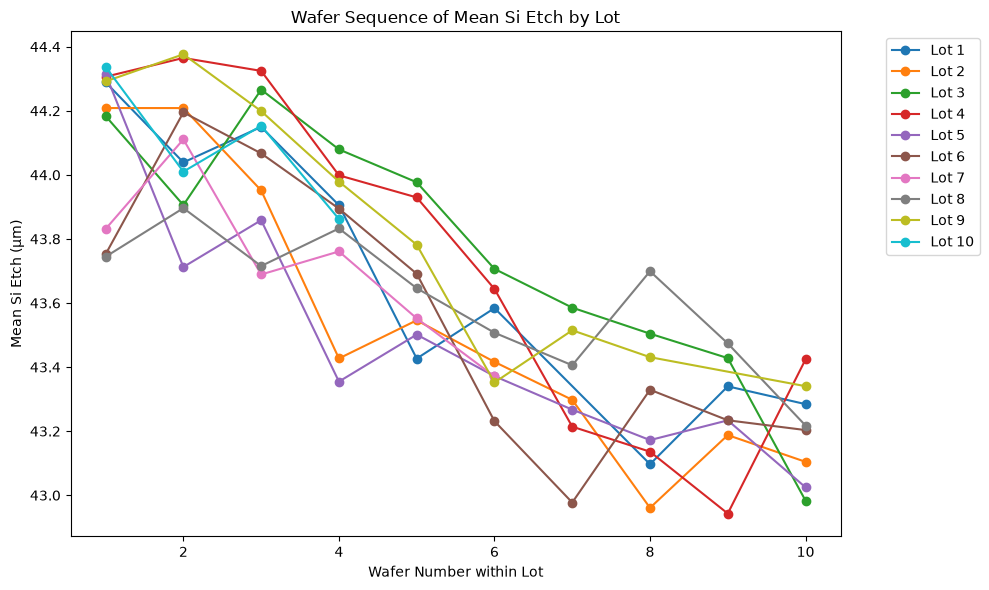

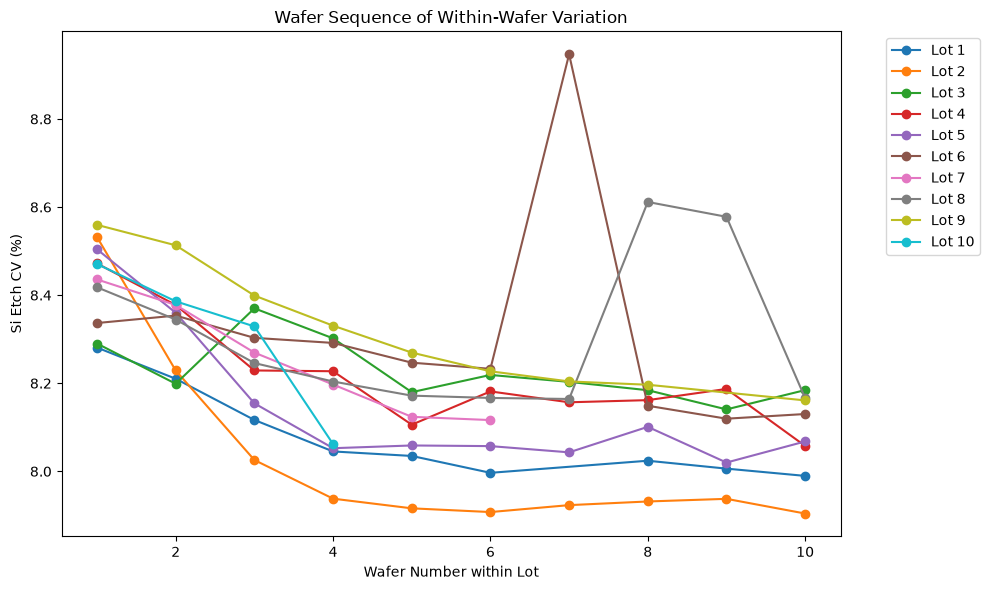

Mean Si Etch slope < 0 的 Lot： 10 / 10
CV slope < 0 的 Lot： 9 / 10


,lot_number,n_wafers,first_measured_wafer,last_measured_wafer,first_mean_si_etch,last_mean_si_etch,observed_change_um,mean_si_etch_slope_per_wafer,mean_si_etch_linear_r2,cv_slope_per_wafer,cv_linear_r2
0,1,9,1,10,44.2890,43.2844,-1.0046,-0.1232,0.8342,-0.0278,0.7236
1,2,10,1,10,44.2086,43.1043,-1.1043,-0.1367,0.8571,-0.0498,0.5477
2,3,10,1,10,44.1835,42.9831,-1.2005,-0.1194,0.8299,-0.0154,0.4380
3,4,10,1,10,44.3063,43.4240,-0.8823,-0.1605,0.8362,-0.0336,0.6747
4,5,10,1,10,44.3142,43.0246,-1.2896,-0.1138,0.8042,-0.0400,0.5677
5,6,10,1,10,43.7522,43.2034,-0.5488,-0.1125,0.6693,-0.0140,0.0317
6,7,6,1,6,43.8311,43.3709,-0.4603,-0.1116,0.6856,-0.0695,0.9626
7,8,10,1,10,43.7445,43.2175,-0.5269,-0.0558,0.6500,0.0065,0.0128
8,9,9,1,10,44.2917,43.3404,-0.9513,-0.1321,0.8627,-0.0464,0.8915
9,10,4,1,4,44.3371,43.8622,-0.4749,-0.1282,0.6659,-0.1283,0.8809


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

for lot_number, group in wafer_quality_df.groupby("lot_number"):
    group = group.sort_values("wafer_number")
    ax.plot(
        group["wafer_number"],
        group["mean_si_etch"],
        marker="o",
        label=f"Lot {lot_number}",
    )

ax.set_xlabel("Wafer Number within Lot")
ax.set_ylabel("Mean Si Etch (µm)")
ax.set_title("Wafer Sequence of Mean Si Etch by Lot")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "wafer_sequence_mean_si_etch.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

for lot_number, group in wafer_quality_df.groupby("lot_number"):
    group = group.sort_values("wafer_number")
    ax.plot(
        group["wafer_number"],
        group["cv_si_etch_pct"],
        marker="o",
        label=f"Lot {lot_number}",
    )

ax.set_xlabel("Wafer Number within Lot")
ax.set_ylabel("Si Etch CV (%)")
ax.set_title("Wafer Sequence of Within-Wafer Variation")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


def fit_linear_trend(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    slope, intercept = np.polyfit(x, y, deg=1)
    predicted = intercept + slope * x

    ss_total = np.sum((y - y.mean()) ** 2)
    ss_residual = np.sum((y - predicted) ** 2)

    r2 = (
        1 - ss_residual / ss_total
        if ss_total > 0
        else np.nan
    )

    return float(slope), float(intercept), float(r2)


lot_sequence_records = []

for lot_number, group in wafer_quality_df.groupby("lot_number"):
    group = group.sort_values("wafer_number")

    x = group["wafer_number"].to_numpy(dtype=float)
    mean_y = group["mean_si_etch"].to_numpy(dtype=float)
    cv_y = group["cv_si_etch_pct"].to_numpy(dtype=float)

    mean_slope, _, mean_r2 = fit_linear_trend(x, mean_y)
    cv_slope, _, cv_r2 = fit_linear_trend(x, cv_y)

    lot_sequence_records.append(
        {
            "lot_number": lot_number,
            "n_wafers": len(group),
            "first_measured_wafer": int(group["wafer_number"].iloc[0]),
            "last_measured_wafer": int(group["wafer_number"].iloc[-1]),
            "first_mean_si_etch": mean_y[0],
            "last_mean_si_etch": mean_y[-1],
            "observed_change_um": mean_y[-1] - mean_y[0],
            "mean_si_etch_slope_per_wafer": mean_slope,
            "mean_si_etch_linear_r2": mean_r2,
            "cv_slope_per_wafer": cv_slope,
            "cv_linear_r2": cv_r2,
        }
    )

lot_sequence_summary = pd.DataFrame(lot_sequence_records)

negative_mean_slopes = int(
    (lot_sequence_summary["mean_si_etch_slope_per_wafer"] < 0).sum()
)

negative_cv_slopes = int(
    (lot_sequence_summary["cv_slope_per_wafer"] < 0).sum()
)

print(
    "Mean Si Etch slope < 0 的 Lot：",
    negative_mean_slopes,
    "/",
    len(lot_sequence_summary),
)
print(
    "CV slope < 0 的 Lot：",
    negative_cv_slopes,
    "/",
    len(lot_sequence_summary),
)

lot_sequence_summary.round(4)

### 這個結果代表什麼？

這一格是 02 最重要的結果之一。

**10 / 10 個 Lots 的 Mean Si Etch slope 全部都是負值**，範圍大約是 **-0.0558 到 -0.1605 µm / wafer**，而且各 Lot 的 linear R² 約在 **0.65–0.86**。

實際看第一片到最後一片有 Measurement 的 Wafer：

- Lot 1 約下降 **1.00 µm**
- Lot 2 約下降 **1.10 µm**
- Lot 3 約下降 **1.20 µm**
- Lot 5 約下降 **1.29 µm**

所以這不是只有某一個 Lot 剛好往下，而是 10 個 Lot 都出現同方向的變化。這代表資料裡有很明顯的 **Within-Lot Mean Si Etch Sequence Effect**：同一個 Lot 裡，越後面的 Wafer，平均 Si Etch 整體越低。

CV 則是 **9 / 10 Lots** slope 為負，而且 R² 差異比較大，所以 CV 的 sequence pattern 沒有 Mean Si Etch 這麼一致。

這個結果也直接決定後面的分析方向：03 要先確認 Process signals 是否也跟 wafer sequence 一起變。如果 Process 和 Quality 都一起隨 sequence 變化，那 04 就不能直接做 pooled correlation，不然很容易把共同的 sequence trend 誤認成 Process 對 Quality 的直接關係。


# Part C｜Spatial Pattern

## 8. 89 個位置的 Spatial Pattern 是否每片都類似？

Wafer mean 只能告訴我整片的平均 Etch Level，還看不出 89 個位置的高低形狀是不是固定的。

所以這裡做三件事：

1. 找一片 Mean Si Etch 最接近全體 median 的 Wafer 當代表。
2. 用 88 片 Wafer 算平均 spatial template。
3. 對每片 Wafer 都用「其他 87 片」的平均 pattern 做 correlation。

這樣做 leave-one-wafer-out，是避免拿某片 Wafer 自己參與建立 template，再回頭跟自己比較，讓相關看起來太高。


Representative Wafer： 2024-08-05_03
Representative Mean Si Etch： 43.689


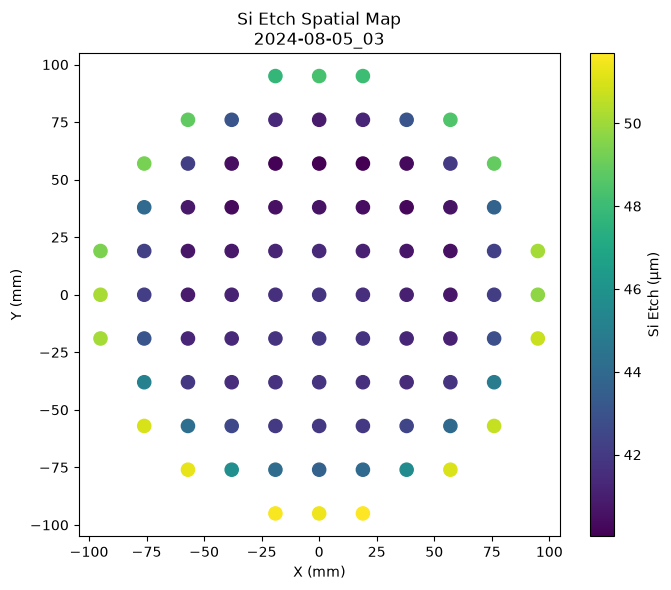

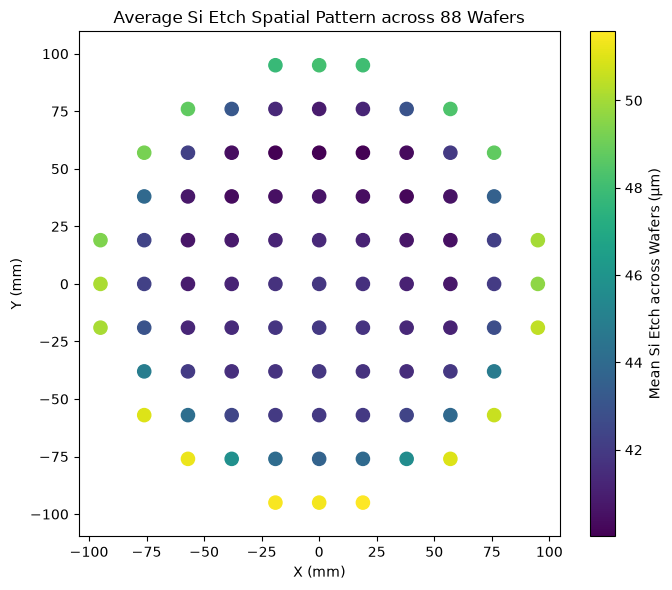

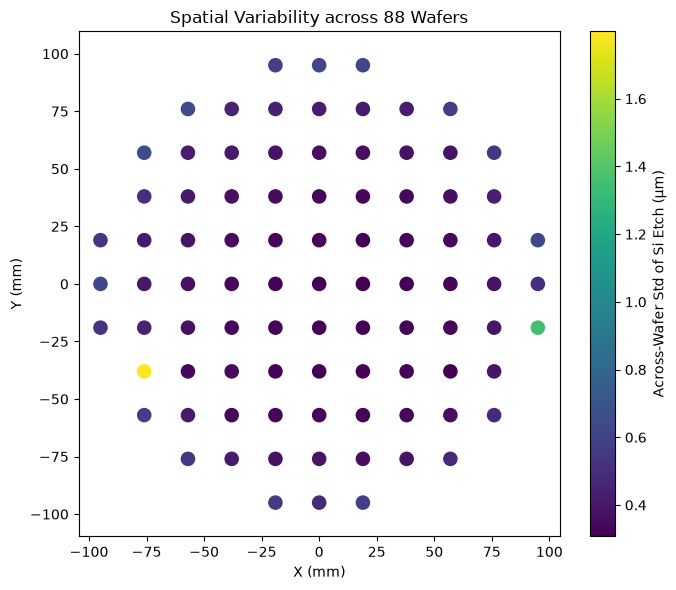

count    88.000000
mean      0.997756
std       0.012284
min       0.900253
25%       0.999536
50%       0.999720
75%       0.999796
max       0.999912
Name: leave_one_out_corr, dtype: float64

In [8]:
overall_median_mean = wafer_quality_df["mean_si_etch"].median()

representative_index = (
    (wafer_quality_df["mean_si_etch"] - overall_median_mean)
    .abs()
    .idxmin()
)

representative_wafer = wafer_quality_df.loc[representative_index]
representative_key = representative_wafer["experiment_key"]

representative_points = measurement_df.loc[
    measurement_df["experiment_key"] == representative_key
]

print("Representative Wafer：", representative_key)
print(
    "Representative Mean Si Etch：",
    round(representative_wafer["mean_si_etch"], 4),
)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    representative_points["x_mm"],
    representative_points["y_mm"],
    c=representative_points["si_etch"],
    s=90,
)
plt.colorbar(scatter, ax=ax, label="Si Etch (µm)")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_title(f"Si Etch Spatial Map\n{representative_key}")
ax.axis("equal")
plt.tight_layout()
plt.show()

spatial_position_summary = (
    measurement_df
    .groupby(["x_mm", "y_mm", "radius_mm"], as_index=False)
    .agg(
        mean_si_etch=("si_etch", "mean"),
        std_si_etch_across_wafers=(
            "si_etch",
            lambda x: x.std(ddof=0),
        ),
        n_wafers=("experiment_key", "nunique"),
    )
)

assert len(spatial_position_summary) == 89
assert spatial_position_summary["n_wafers"].eq(88).all()

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    spatial_position_summary["x_mm"],
    spatial_position_summary["y_mm"],
    c=spatial_position_summary["mean_si_etch"],
    s=90,
)
plt.colorbar(
    scatter,
    ax=ax,
    label="Mean Si Etch across Wafers (µm)",
)
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_title("Average Si Etch Spatial Pattern across 88 Wafers")
ax.axis("equal")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "average_si_etch_spatial_map.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    spatial_position_summary["x_mm"],
    spatial_position_summary["y_mm"],
    c=spatial_position_summary["std_si_etch_across_wafers"],
    s=90,
)
plt.colorbar(
    scatter,
    ax=ax,
    label="Across-Wafer Std of Si Etch (µm)",
)
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_title("Spatial Variability across 88 Wafers")
ax.axis("equal")
plt.tight_layout()
plt.show()

spatial_matrix = measurement_df.pivot(
    index="experiment_key",
    columns=["x_mm", "y_mm"],
    values="si_etch",
)

assert spatial_matrix.shape == (88, 89)
assert not spatial_matrix.isna().any().any()

spatial_sum = spatial_matrix.sum(axis=0)
spatial_similarity_records = []

for experiment_key, row in spatial_matrix.iterrows():
    leave_one_out_template = (
        spatial_sum - row
    ) / (len(spatial_matrix) - 1)

    spatial_similarity_records.append(
        {
            "experiment_key": experiment_key,
            "leave_one_out_corr": row.corr(leave_one_out_template),
        }
    )

spatial_similarity_df = pd.DataFrame(spatial_similarity_records)

spatial_similarity_df["leave_one_out_corr"].describe()

### 這個結果代表什麼？

選到的代表 Wafer 是 `2024-08-05_03`，Mean Si Etch 約 **43.689 µm**。

更重要的是 88 片 Wafer 的 leave-one-out spatial correlation：

- 平均 ≈ **0.9978**
- 中位數 ≈ **0.9997**
- 最低也還有 ≈ **0.9003**

這些值非常高，表示不同 Wafer 的 89-point 高低形狀幾乎都很像。也就是說，片內 Spatial Variation 不是每片隨機出現不同圖案，而是有一個非常穩定、可以重現的共同 pattern。

這個 correlation 看的是「形狀像不像」，不是說每片 Wafer 的絕對 Etch 數值完全一樣。


## 9. 找出 Across-Wafer 變異特別大的空間位置

雖然整體 spatial pattern 很穩定，但還是可能有少數固定位置在不同 Wafer 間特別容易出現極端值。

所以我先找 across-wafer std 最高的 5 個位置，再看最極端的低值出現在哪一片 Wafer，最後做一個簡單的 sensitivity check：暫時拿掉那個點後，Wafer 的 Mean / CV / Range 會改多少。

這只是找「值得再看」的位置，不是正式的 outlier test，所以不會因為這裡看到極端值就直接刪資料。


In [9]:
top_spatial_positions = (
    spatial_position_summary
    .nlargest(5, "std_si_etch_across_wafers")
    [
        [
            "x_mm",
            "y_mm",
            "radius_mm",
            "mean_si_etch",
            "std_si_etch_across_wafers",
        ]
    ]
)

spatial_variability_records = []

for _, position in top_spatial_positions.iterrows():
    position_data = measurement_df.loc[
        (measurement_df["x_mm"] == position["x_mm"])
        & (measurement_df["y_mm"] == position["y_mm"])
    ]

    min_row = position_data.loc[position_data["si_etch"].idxmin()]
    max_row = position_data.loc[position_data["si_etch"].idxmax()]

    spatial_variability_records.append(
        {
            "x_mm": position["x_mm"],
            "y_mm": position["y_mm"],
            "radius_mm": position["radius_mm"],
            "mean_si_etch": position["mean_si_etch"],
            "across_wafer_std": position["std_si_etch_across_wafers"],
            "min_si_etch": min_row["si_etch"],
            "min_wafer": min_row["experiment_key"],
            "max_si_etch": max_row["si_etch"],
            "max_wafer": max_row["experiment_key"],
        }
    )

spatial_variability_hotspots = pd.DataFrame(
    spatial_variability_records
)

display(spatial_variability_hotspots)

sensitivity_records = []

for _, row in spatial_variability_hotspots.head(2).iterrows():
    wafer_key = row["min_wafer"]

    wafer_points = measurement_df.loc[
        measurement_df["experiment_key"] == wafer_key
    ].copy()

    flagged_mask = (
        (wafer_points["x_mm"] == row["x_mm"])
        & (wafer_points["y_mm"] == row["y_mm"])
    )

    assert flagged_mask.sum() == 1

    original_mean = wafer_points["si_etch"].mean()
    original_std = wafer_points["si_etch"].std(ddof=0)
    original_cv = original_std / original_mean * 100
    original_range = wafer_points["si_etch"].max() - wafer_points["si_etch"].min()

    without_flagged = wafer_points.loc[~flagged_mask]

    new_mean = without_flagged["si_etch"].mean()
    new_std = without_flagged["si_etch"].std(ddof=0)
    new_cv = new_std / new_mean * 100
    new_range = without_flagged["si_etch"].max() - without_flagged["si_etch"].min()

    sensitivity_records.append(
        {
            "experiment_key": wafer_key,
            "x_mm": row["x_mm"],
            "y_mm": row["y_mm"],
            "flagged_si_etch": wafer_points.loc[
                flagged_mask,
                "si_etch",
            ].iloc[0],
            "original_mean_si_etch": original_mean,
            "mean_without_flagged_point": new_mean,
            "original_cv_pct": original_cv,
            "cv_without_flagged_point_pct": new_cv,
            "original_range_si_etch": original_range,
            "range_without_flagged_point": new_range,
            "range_change": new_range - original_range,
        }
    )

point_sensitivity_df = pd.DataFrame(sensitivity_records)

point_sensitivity_df

,x_mm,y_mm,radius_mm,mean_si_etch,across_wafer_std,min_si_etch,min_wafer,max_si_etch,max_wafer
0,-76.0,-38.0,84.970583,44.889500,1.799080,28.6530,2024-08-01_07,45.9535,2024-07-02_01
1,95.0,-19.0,96.881371,50.468641,1.351982,39.2308,2024-07-09_02,51.9154,2024-07-05_01
2,-76.0,57.0,95.000000,49.212513,0.649203,48.0977,2024-07-05_08,50.6097,2024-07-02_01
3,-57.0,76.0,95.000000,48.772633,0.639878,47.6911,2024-07-05_08,50.0913,2024-07-02_01
4,95.0,19.0,96.881371,50.000985,0.638142,48.9086,2024-07-05_08,51.3694,2024-07-19_01


,experiment_key,x_mm,y_mm,flagged_si_etch,original_mean_si_etch,mean_without_flagged_point,original_cv_pct,cv_without_flagged_point_pct,original_range_si_etch,range_without_flagged_point,range_change
0,2024-08-01_07,-76.0,-38.0,28.6530,42.977328,43.140105,8.946925,8.226561,22.3004,11.4514,-10.8490
1,2024-07-09_02,95.0,-19.0,39.2308,43.905554,43.958676,8.198847,8.156042,12.8170,11.6599,-1.1571


### 這個結果代表什麼？

最明顯的位置是：

- `X = -76 mm, Y = -38 mm`
- `2024-08-01_07` 在這裡的 Si Etch = **28.653 µm**

這個值比同一位置其他 Wafer 明顯低，也讓這個位置的 across-wafer std 變成最高。

對 `2024-08-01_07` 做 sensitivity check 後：

- 原始 CV ≈ **8.95%**
- 暫時拿掉這一點後 CV ≈ **8.23%**

所以這個單一低值確實明顯放大了這片 Wafer 的 CV；上方 sensitivity table 現在也會直接列出 `original_range_si_etch`、`range_without_flagged_point` 與 `range_change`，讓 Range 的影響由實際 before / after 數值支持，而不是只靠推論。

第二個值得看的位置是 `X = 95 mm, Y = -19 mm`，`2024-07-09_02` 的值約 **39.23 µm**。但把它拿掉後，CV 只從約 **8.20% 降到 8.16%**，影響小很多。

目前資料無法判斷這些極端點到底是局部製程現象還是量測問題，所以合理做法是**保留原始資料，標記成後續調查對象**，而不是直接刪除。


## 10. Radial Etch Pattern

前面的 Spatial Map 看起來很像有 edge effect，所以這裡把位置依 `radius_mm` 分成幾個區域，再特別比較：

- Inner：`radius < 75 mm`
- Outer：`radius >= 75 mm`

75 mm 只是這份分析用的切點，不是製造規格或設備界線。


,radius_region,n_points,mean_si_etch,std_si_etch,n_wafers
0,0–<25 mm,440,41.687677,0.378773,88
1,25–<50 mm,1408,41.188979,0.569756,88
2,50–<75 mm,2112,41.062537,0.852041,88
3,>=75 mm,3872,46.215903,3.598715,88


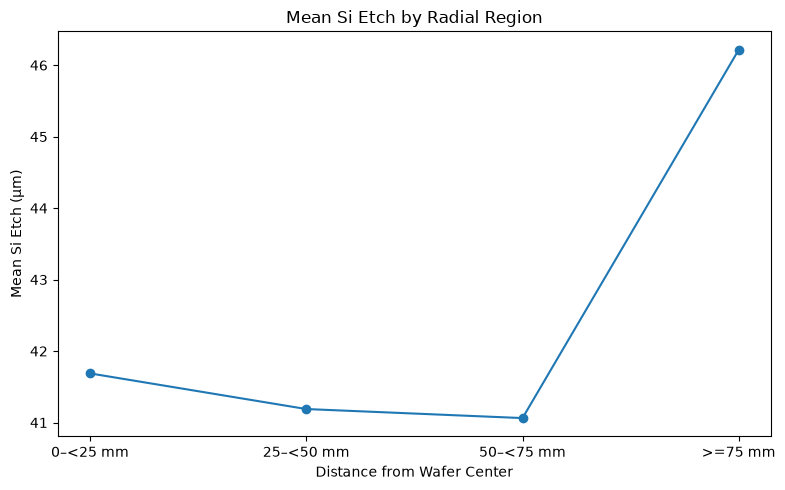

Outer Mean： 46.2159
Inner Mean： 41.177
平均 Outer - Inner： 5.0389
88 片是否全部 Outer > Inner： True


count    88.000000
mean      5.038948
std       0.172627
min       4.619301
25%       4.926244
50%       5.046237
75%       5.169816
max       5.402817
Name: outer_minus_inner, dtype: float64

In [10]:
measurement_df["radius_region"] = pd.cut(
    measurement_df["radius_mm"],
    bins=[0, 25, 50, 75, np.inf],
    right=False,
    include_lowest=True,
    labels=[
        "0–<25 mm",
        "25–<50 mm",
        "50–<75 mm",
        ">=75 mm",
    ],
)

radial_summary = (
    measurement_df
    .groupby("radius_region", observed=True)
    .agg(
        n_points=("si_etch", "size"),
        mean_si_etch=("si_etch", "mean"),
        std_si_etch=("si_etch", lambda x: x.std(ddof=0)),
        n_wafers=("experiment_key", "nunique"),
    )
    .reset_index()
)

display(radial_summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    radial_summary["radius_region"].astype(str),
    radial_summary["mean_si_etch"],
    marker="o",
)
ax.set_xlabel("Distance from Wafer Center")
ax.set_ylabel("Mean Si Etch (µm)")
ax.set_title("Mean Si Etch by Radial Region")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "radial_si_etch_pattern.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

measurement_df["radial_zone"] = np.where(
    measurement_df["radius_mm"] >= 75,
    "Outer (>=75 mm)",
    "Inner (<75 mm)",
)

wafer_radial_zone = (
    measurement_df
    .groupby(["experiment_key", "radial_zone"], as_index=False)
    .agg(mean_si_etch=("si_etch", "mean"))
)

wafer_radial_pivot = wafer_radial_zone.pivot(
    index="experiment_key",
    columns="radial_zone",
    values="mean_si_etch",
)

assert not wafer_radial_pivot.isna().any().any()

wafer_radial_pivot["outer_minus_inner"] = (
    wafer_radial_pivot["Outer (>=75 mm)"]
    - wafer_radial_pivot["Inner (<75 mm)"]
)

print(
    "Outer Mean：",
    round(wafer_radial_pivot["Outer (>=75 mm)"].mean(), 4),
)
print(
    "Inner Mean：",
    round(wafer_radial_pivot["Inner (<75 mm)"].mean(), 4),
)
print(
    "平均 Outer - Inner：",
    round(wafer_radial_pivot["outer_minus_inner"].mean(), 4),
)
print(
    "88 片是否全部 Outer > Inner：",
    (wafer_radial_pivot["outer_minus_inner"] > 0).all(),
)

wafer_radial_pivot["outer_minus_inner"].describe()

### 這個結果代表什麼？

結果非常一致：

- Outer Mean ≈ **46.22 µm**
- Inner Mean ≈ **41.18 µm**
- 平均 Outer - Inner ≈ **+5.04 µm**
- **88 / 88 片 Wafer** 都是 Outer > Inner
- 每片 Outer - Inner 大約落在 **+4.62 到 +5.40 µm**

這代表「外圍 Etch 比內部深」不是被少數幾片 Wafer 拉出來的，而是 88 片全部都存在的共同 radial pattern。

所以在這份資料中，可以很明確地描述：**靠近 Wafer 外圍的位置，Silicon Etch Depth 系統性高於內部。**

但這裡只有 Measurement Data，還不能靠這個結果直接判定背後的物理原因。


# Part D｜Interpolation Sensitivity

## 11. Post-Oxide Interpolation 數量會不會主導 Wafer KPI？

01 已經確認 `si_etch = stepheight - postox_thickness`，所以 post-oxide 被重建的位置會把這份不確定性帶進 Si Etch。

這裡我只問一個比較保守的問題：

> 一片 Wafer 的 interpolation points 越多，它的 Mean Si Etch 或 CV 會不會也明顯跟著改變？

我用 Pearson 和 Spearman 看這個關係。就算相關很低，也只能說「沒有明顯的 count–KPI 關係」，不能反過來證明 interpolation 完全沒有影響。


,metric,pearson,spearman
0,Mean Si Etch,0.129445,0.125761
1,CV,0.022545,0.010297


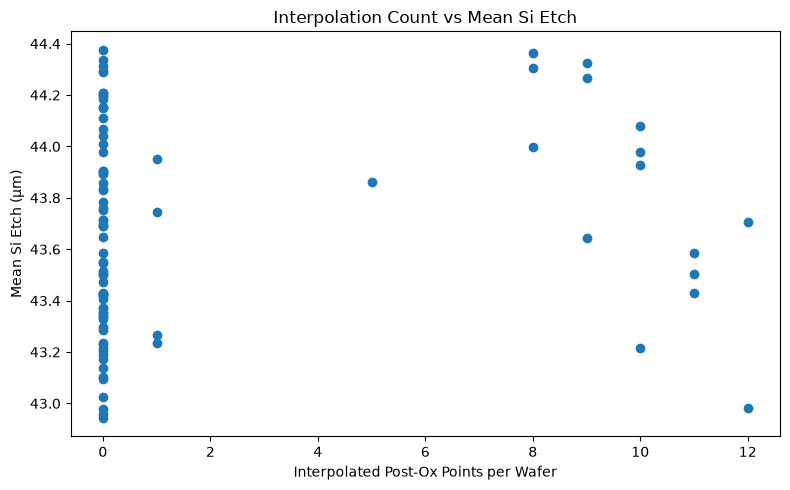

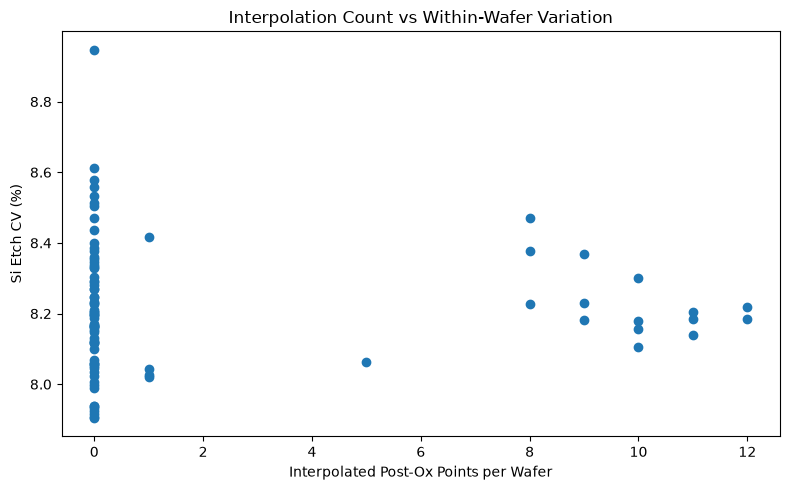

In [11]:
interpolation_correlation = pd.DataFrame(
    {
        "metric": ["Mean Si Etch", "CV"],
        "pearson": [
            wafer_quality_df["interpolated_points"].corr(
                wafer_quality_df["mean_si_etch"],
                method="pearson",
            ),
            wafer_quality_df["interpolated_points"].corr(
                wafer_quality_df["cv_si_etch_pct"],
                method="pearson",
            ),
        ],
        "spearman": [
            wafer_quality_df["interpolated_points"].corr(
                wafer_quality_df["mean_si_etch"],
                method="spearman",
            ),
            wafer_quality_df["interpolated_points"].corr(
                wafer_quality_df["cv_si_etch_pct"],
                method="spearman",
            ),
        ],
    }
)

display(interpolation_correlation)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    wafer_quality_df["interpolated_points"],
    wafer_quality_df["mean_si_etch"],
)
ax.set_xlabel("Interpolated Post-Ox Points per Wafer")
ax.set_ylabel("Mean Si Etch (µm)")
ax.set_title("Interpolation Count vs Mean Si Etch")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    wafer_quality_df["interpolated_points"],
    wafer_quality_df["cv_si_etch_pct"],
)
ax.set_xlabel("Interpolated Post-Ox Points per Wafer")
ax.set_ylabel("Si Etch CV (%)")
ax.set_title("Interpolation Count vs Within-Wafer Variation")
plt.tight_layout()
plt.show()

### 這個結果代表什麼？

Interpolation count 和兩個 Wafer KPI 的相關都很低：

| KPI | Pearson | Spearman |
|---|---:|---:|
| Mean Si Etch | 約 0.129 | 約 0.126 |
| CV | 約 0.023 | 約 0.010 |

所以目前看不出「一片 Wafer 插值點越多，Mean Si Etch 或 CV 就會固定變高或變低」的趨勢，尤其 CV 幾乎沒有關聯。

這個結果只能說 interpolation **數量**沒有主導 Wafer-level KPI；它不能證明每個重建位置都完全沒有量測不確定性，所以 01 建立的 interpolation flag 還是要保留。


## 12. 找出資料裡相對極端的 Wafer

最後把 Mean Si Etch 最高、最低，以及 CV 最高的 Wafer 列出來，讓後面的 SPC / anomaly analysis 有可以追蹤的對象。

這裡沒有正式 manufacturing specification，所以我只稱它們為 **Relative Extreme Wafers**。它們只是相對於這份資料比較極端，不代表 Defect、Failure 或 Bad Wafer。


In [12]:
highest_mean_wafers = (
    wafer_quality_df
    .nlargest(5, "mean_si_etch")
    [
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "mean_si_etch",
            "cv_si_etch_pct",
            "interpolated_points",
        ]
    ]
)

lowest_mean_wafers = (
    wafer_quality_df
    .nsmallest(5, "mean_si_etch")
    [
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "mean_si_etch",
            "cv_si_etch_pct",
            "interpolated_points",
        ]
    ]
)

highest_variation_wafers = (
    wafer_quality_df
    .nlargest(5, "cv_si_etch_pct")
    [
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "mean_si_etch",
            "std_si_etch",
            "cv_si_etch_pct",
            "range_si_etch",
            "p90_width_si_etch",
            "interpolated_points",
        ]
    ]
)

print("Highest Mean Si Etch")
display(highest_mean_wafers)

print("\nLowest Mean Si Etch")
display(lowest_mean_wafers)

print("\nHighest CV")
display(highest_variation_wafers)

Highest Mean Si Etch


,experiment_key,lot_number,wafer_number,mean_si_etch,cv_si_etch_pct,interpolated_points
76,2024-08-21_02,9,2,44.376304,8.513214,0
30,2024-07-11_02,4,2,44.364903,8.377681,8
84,2024-08-22_01,10,1,44.337099,8.470729,0
31,2024-07-11_03,4,3,44.324506,8.229032,9
39,2024-07-19_01,5,1,44.314201,8.504150,0



Lowest Mean Si Etch


,experiment_key,lot_number,wafer_number,mean_si_etch,cv_si_etch_pct,interpolated_points
37,2024-07-11_09,4,9,42.942928,8.187082,0
16,2024-07-05_08,2,8,42.960672,7.931542,0
55,2024-08-01_07,6,7,42.977328,8.946925,0
28,2024-07-09_10,3,10,42.983073,8.184442,12
48,2024-07-19_10,5,10,43.024626,8.067814,0



Highest CV


,experiment_key,lot_number,wafer_number,mean_si_etch,std_si_etch,cv_si_etch_pct,range_si_etch,p90_width_si_etch,interpolated_points
55,2024-08-01_07,6,7,42.977328,3.845149,8.946925,22.3004,10.62454,0
72,2024-08-07_08,8,8,43.699084,3.763192,8.611605,12.0491,11.05408,0
73,2024-08-07_09,8,9,43.473815,3.729154,8.577932,12.0516,10.98000,0
75,2024-08-21_01,9,1,44.291687,3.791207,8.559635,12.1549,10.98714,0
9,2024-07-05_01,2,1,44.208571,3.771851,8.531945,12.2361,11.12328,0


### 這個結果代表什麼？

目前最明顯的幾個相對極端值是：

- Mean Si Etch 最高：`2024-08-21_02`，約 **44.376 µm**
- Mean Si Etch 最低：`2024-07-11_09`，約 **42.943 µm**
- CV 最高：`2024-08-01_07`，約 **8.947%**

其中 `2024-08-01_07` 正好也是前面出現 **28.653 µm** 單一極低 spatial point 的 Wafer，所以「CV 最高」和前面的 sensitivity check 能前後對上：它的高變異確實有一部分被這個極端位置放大。

不過這些值都只是相對於目前 88 片 Wafer 的高低排序，沒有規格線，所以不能把它們直接叫做超規或不良品。


## 13. 輸出給後續 Notebook 使用的 Quality 表格

02 最後把已經整理好的結果輸出成：

- `wafer_quality_summary.csv`
- `lot_quality_summary.csv`
- `lot_sequence_summary.csv`
- `spatial_position_summary.csv`
- `radial_summary.csv`
- `spatial_variability_hotspots.csv`

其中最重要的是 `lot_sequence_summary.csv`，因為 03 可以直接讀這份結果，接著檢查 Process signals 是否也有 sequence trend，不需要再把 02 做過的 Quality sequence analysis 重算一次。


In [13]:
output_tables = {
    "wafer_quality_summary.csv": wafer_quality_df,
    "lot_quality_summary.csv": lot_quality_summary,
    "lot_sequence_summary.csv": lot_sequence_summary,
    "spatial_position_summary.csv": spatial_position_summary,
    "radial_summary.csv": radial_summary,
    "spatial_variability_hotspots.csv": spatial_variability_hotspots,
}

for filename, dataframe in output_tables.items():
    dataframe.to_csv(
        PROCESSED_DATA_DIR / filename,
        index=False,
    )

output_checks = []

for filename, dataframe in output_tables.items():
    output_path = PROCESSED_DATA_DIR / filename
    reloaded = pd.read_csv(output_path)

    output_checks.append(
        {
            "file": filename,
            "exists": output_path.exists(),
            "rows_match": len(reloaded) == len(dataframe),
            "columns_match": list(reloaded.columns) == list(dataframe.columns),
        }
    )

output_checks_df = pd.DataFrame(output_checks)

assert output_checks_df[
    ["exists", "rows_match", "columns_match"]
].all().all()

assert len(pd.read_csv(
    PROCESSED_DATA_DIR / "wafer_quality_summary.csv"
)) == 88

assert len(pd.read_csv(
    PROCESSED_DATA_DIR / "lot_sequence_summary.csv"
)) == 10

output_checks_df

,file,exists,rows_match,columns_match
0,wafer_quality_summary.csv,True,True,True
1,lot_quality_summary.csv,True,True,True
2,lot_sequence_summary.csv,True,True,True
3,spatial_position_summary.csv,True,True,True
4,radial_summary.csv,True,True,True
5,spatial_variability_hotspots.csv,True,True,True


### 這個結果代表什麼？

6 個輸出檔的：

- `exists`
- `rows_match`
- `columns_match`

全部都是 `True`。

所以不只檔案有成功寫出去，重新讀回後的 row 數和欄位也都和記憶體中的結果一致。這代表 02 的輸出可以安全交給 03 使用；如果其中任何一項不是 `True`，流程就應該停在這裡先查原因。


# 14. 這份 Notebook 的整體結論

02 做完後，Wafer Quality 的主要變化方式已經很清楚了。

先看 Wafer 整體平均值。88 片 Wafer 的 `mean_si_etch` 平均約 **43.67 µm**，不同 Wafer 的 Mean Si Etch 標準差約 **0.40 µm**，所以 Wafer 與 Wafer 之間的整體 Etch Level 確實會變，但幅度相對沒有片內差異那麼大。每片 Wafer 內部的 `std_si_etch` 平均約 **3.59 µm**、CV 約 **8.21%**，代表同一片 Wafer 不同位置之間的差異其實很明顯，不能只看整片平均值就判斷品質。

Lot 平均值大約落在 **43.48–44.09 µm**，表示 Lot 之間確實有一些位移。不過目前只有觀察到差異，還不能直接把差異歸因到 Conditioning。

更重要的是 Wafer sequence。**10 / 10 個 Lots 的 Mean Si Etch slope 全部都是負值**，而且多個 Lot 從第一片到最後一片都下降接近 1 µm。這表示「同一個 Lot 裡越後面的 Wafer，平均 Si Etch 越低」不是只有某一個 Lot 才出現，而是這批資料很一致的變化方向。這會直接影響後面的 Process–Quality 分析：如果某些 Process signals 也會跟 wafer number 一起變，就不能看到兩者有 correlation 就直接說 Process signal 和 Quality 有關，必須先把 wafer sequence 造成的共同趨勢處理掉。

Spatial pattern 也很一致。88 片 Wafer 和 leave-one-out 平均空間分布的相關係數平均約 **0.9978**，而且 **88 / 88 片都是 Outer Mean > Inner Mean**。Outer Mean 約 **46.22 µm**、Inner Mean 約 **41.18 µm**，平均差約 **+5.04 µm**。這表示片內不均勻不是每片 Wafer 隨機長成不同形狀，而是反覆出現同一種 radial pattern：靠近外圍的位置 Si Etch 明顯比較高。

另外也找到少數值得注意的空間極端點。最明顯的是 `2024-08-01_07` 在 `(X=-76 mm, Y=-38 mm)` 的 **28.653 µm**。把這一點暫時拿掉後，該片 CV 會從約 **8.95% 降到 8.23%**；Section 9 的 sensitivity table 也會直接列出 Range 移除前後的數值，因此可以分開確認這個點對 CV 與 Range 的實際影響。不過現在還沒有證據能判斷它是局部製程現象還是量測問題，所以正確做法是保留它，當成後面值得調查的 case，而不是直接刪掉。

最後，interpolation point 數量和 Mean Si Etch / CV 的相關都很低：Mean 的相關大約只有 **0.13**，CV 幾乎接近 **0**。所以目前沒有看到「重建點越多，Wafer KPI 就一定越差」的明顯關係。不過這只代表 interpolation count 和這兩個 KPI 沒有明顯一起變，不能反過來說重建值完全沒有不確定性。

所以 02 最重要的統整結果有兩個：**第一，Quality 有很一致的 within-Lot wafer sequence effect；第二，Wafer 內部有非常穩定的 radial spatial pattern。** 下一份 03 就要接著看 Process signals 有沒有類似的 sequence 變化。只有先把這件事確認清楚，04 才能比較合理地分析 Process 和 Quality 之間的關係，而不會被 wafer sequence 的共同趨勢誤導。